# Distance Threshold Exceedance Analysis
## Proportion of SALs Beyond Pharmacy Access Thresholds

**Tess Vu**

Binary accessibility screening: for each SAL, does a pharmacy exist
within a given network distance threshold? This complements the 2SFCA
by providing a policy-legible metric that avoids decay functions,
demand-weighting, and provincial quantiles. The question is simple:
**can people physically reach medication or not?**

Thresholds are applied to pre-computed k=1 nearest-pharmacy distances
(Euclidean, pedestrian network, drive network) from SAL centroids.

## SETUP AND IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## CONFIGURATION

All file paths and threshold definitions in a single cell.
Thresholds are set once and used throughout the notebook.

In [4]:
# FILE PATHS
# Pre-computed SAL-to-nearest-pharmacy distances (output of sal_pharmacy_distance notebook).
DISTANCE_CSV = "data/networks/sal_pharmacy_distances.csv"

# Population estimates with settlement type classifications.
POP_CSV = "data/pop_pred_final.csv"

# DISTANCE THRESHOLDS (kilometers)
# Walking thresholds reflect pedestrian-realistic access bands.
WALK_THRESHOLDS_KM = [1, 2, 3, 5]

# Driving thresholds reflect vehicle-based access bands.
DRIVE_THRESHOLDS_KM = [5, 10, 15, 20]

# Euclidean thresholds for straight-line baseline comparison.
EUCLIDEAN_THRESHOLDS_KM = [1, 3, 5, 10]

# PROVINCE LOOKUP from EA_CODE first digit.
# Stats SA geographic coding: 5 = KwaZulu-Natal, 7 = Gauteng.
PROVINCE_MAP = {
    "5": "KwaZulu-Natal",
    "7": "Gauteng"
}

# Settlement type display order.
SETTLEMENT_ORDER = ["Urban", "Traditional", "Farms"]

## LOAD DATA

In [5]:
# Load pre-computed SAL-to-pharmacy distances.
dist_raw = pd.read_csv(DISTANCE_CSV)
print(f"DISTANCE DATA LOADED: {dist_raw.shape[0]} rows, {dist_raw.shape[1]} columns")
print(f"Columns: {list(dist_raw.columns)}")
print()

# Load population and settlement type data.
pop_raw = pd.read_csv(POP_CSV)
print(f"POPULATION DATA LOADED: {pop_raw.shape[0]} rows, {pop_raw.shape[1]} columns")
print(f"Columns: {list(pop_raw.columns)}")

DISTANCE DATA LOADED: 39177 rows, 14 columns
Columns: ['EA_CODE', 'PR_NAME', 'WardID', 'sal2023_est', 'centroid_lat', 'centroid_lng', 'euclidean_dist_m', 'euclidean_dist_km', 'walk_dist_m', 'walk_dist_km', 'drive_dist_m', 'drive_dist_km', 'walk_circuity', 'drive_circuity']

POPULATION DATA LOADED: 38380 rows, 21 columns
Columns: ['WardID', 'EA_CODE', 'sal2011_pop', 'ward2023_pop', 'EA_GTYPE', 'EA_TYPE', 'econ_status', 'houses2011', 'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other', 'area_km2', 'sal_dense', 'log_density', 'ward2011_sum', 'share2011', 'dasym_weight', 'sal2023_est', 'growth_rate']


## MERGE AND PREPARE ANALYSIS TABLE

Join distances with population attributes (settlement type, economic
status, estimated population). Province is derived from the EA_CODE
prefix as a fallback if not present in the distance file.

In [19]:
# Normalize EA_CODE to int64 on both sides.
dist_raw["EA_CODE"] = pd.to_numeric(dist_raw["EA_CODE"], errors = "coerce").astype("Int64")
pop_raw["EA_CODE"] = pd.to_numeric(pop_raw["EA_CODE"], errors = "coerce").astype("Int64")

# Select relevant columns from population data.
pop_cols = ["EA_CODE", "EA_GTYPE", "EA_TYPE", "econ_status", "sal2023_est", "area_km2"]
pop_subset = pop_raw[pop_cols].copy()

# Drop sal2023_est from distance data if it exists (we want the population version).
dist_raw = dist_raw.drop(columns = ["sal2023_est"], errors = "ignore")

# Merge distance data with population attributes.
df = dist_raw.merge(pop_subset, on = "EA_CODE", how = "left")

print(f"MERGED SHAPE: {df.shape}")
print(f"Match rate: {df['EA_GTYPE'].notna().sum()} / {len(df)} ({df['EA_GTYPE'].notna().mean() * 100:.1f}%)")

MERGED SHAPE: (39177, 18)
Match rate: 39177 / 39177 (100.0%)


In [23]:
# Derive province from EA_CODE if not already present.
if "PR_NAME" not in df.columns:
    df["PR_NAME"] = df["EA_CODE"].astype(str).str[0].map(PROVINCE_MAP)
    print("PROVINCE DERIVED FROM EA_CODE PREFIX")
else:
    print("PROVINCE COLUMN ALREADY PRESENT IN DISTANCE DATA")

print(f"Province distribution:")
print(df["PR_NAME"].value_counts())
print()

# Confirm settlement type distribution.
print("SETTLEMENT TYPE (EA_GTYPE) DISTRIBUTION:")
print(df["EA_GTYPE"].value_counts())
print()

# Drop rows with missing province or settlement type.
before = len(df)
df = df.dropna(subset = ["PR_NAME", "EA_GTYPE"]).copy()
after = len(df)
print(f"ROWS DROPPED (missing province or settlement type): {before - after}")
print(f"ANALYSIS TABLE: {after} SALs")

PROVINCE COLUMN ALREADY PRESENT IN DISTANCE DATA
Province distribution:
PR_NAME
Gauteng          21182
KwaZulu-Natal    17995
Name: count, dtype: int64

SETTLEMENT TYPE (EA_GTYPE) DISTRIBUTION:
EA_GTYPE
Urban          29633
Traditional     8423
Farms           1121
Name: count, dtype: int64

ROWS DROPPED (missing province or settlement type): 0
ANALYSIS TABLE: 39177 SALs


In [24]:
# Identify available distance columns.
dist_col_map = {
    "walk": "walk_dist_km",
    "drive": "drive_dist_km",
    "euclidean": "euclidean_dist_km"
}

available_modes = {}
for mode, col in dist_col_map.items():
    if col in df.columns:
        available_modes[mode] = col
        valid = df[col].notna().sum()
        print(f"  {mode}: column '{col}' found, {valid} valid values ({valid / len(df) * 100:.1f}%)")
    else:
        print(f"  {mode}: column '{col}' NOT FOUND, skipping")

print(f"AVAILABLE DISTANCE MODES: {list(available_modes.keys())}")

  walk: column 'walk_dist_km' found, 39177 valid values (100.0%)
  drive: column 'drive_dist_km' found, 39177 valid values (100.0%)
  euclidean: column 'euclidean_dist_km' found, 39177 valid values (100.0%)
AVAILABLE DISTANCE MODES: ['walk', 'drive', 'euclidean']


## DISTANCE OVERVIEW BY PROVINCE AND SETTLEMENT TYPE

Quick summary statistics before threshold analysis.

In [25]:
# Summary statistics for each distance mode by province.
for mode, col in available_modes.items():
    print(f"DISTANCE SUMMARY: {mode.upper()} (km)")
    summary = df.groupby("PR_NAME")[col].describe(percentiles = [0.25, 0.5, 0.75, 0.9, 0.95])
    print(summary.round(2).to_string())
    print()

DISTANCE SUMMARY: WALK (km)
                   count    mean     std    min    25%    50%     75%     90%     95%     max
PR_NAME                                                                                      
Gauteng       21182.0000  2.4800  2.5800 0.0000 0.9700 1.6900  2.9600  5.4900  7.5000 41.5200
KwaZulu-Natal 17995.0000 11.5600 12.7400 0.0000 1.8900 5.2600 19.4100 31.8900 38.3600 73.5900

DISTANCE SUMMARY: DRIVE (km)
                   count    mean     std    min    25%    50%     75%     90%     95%     max
PR_NAME                                                                                      
Gauteng       21182.0000  2.4600  2.6000 0.0000 0.9200 1.6400  2.9900  5.5400  7.5200 38.5000
KwaZulu-Natal 17995.0000 11.6200 12.8100 0.0000 1.9100 5.3300 19.3500 32.1100 38.5200 70.7800

DISTANCE SUMMARY: EUCLIDEAN (km)
                   count   mean    std    min    25%    50%     75%     90%     95%     max
PR_NAME                                                         

In [26]:
# Summary by province and settlement type.
for mode, col in available_modes.items():
    print(f"MEDIAN {mode.upper()} DISTANCE (km) BY PROVINCE x SETTLEMENT TYPE")
    pivot = df.pivot_table(
        values = col,
        index = "EA_GTYPE",
        columns = "PR_NAME",
        aggfunc = "median"
    )
    pivot = pivot.reindex(SETTLEMENT_ORDER)
    print(pivot.round(2).to_string())
    print()

MEDIAN WALK DISTANCE (km) BY PROVINCE x SETTLEMENT TYPE
PR_NAME      Gauteng  KwaZulu-Natal
EA_GTYPE                           
Urban         1.6400         1.9900
Traditional   4.8200        18.6200
Farms         9.1900        19.4600

MEDIAN DRIVE DISTANCE (km) BY PROVINCE x SETTLEMENT TYPE
PR_NAME      Gauteng  KwaZulu-Natal
EA_GTYPE                           
Urban         1.6000         2.0300
Traditional   4.8900        18.7200
Farms         9.0500        18.9500

MEDIAN EUCLIDEAN DISTANCE (km) BY PROVINCE x SETTLEMENT TYPE
PR_NAME      Gauteng  KwaZulu-Natal
EA_GTYPE                           
Urban         1.1300         1.3000
Traditional   3.8500        13.2000
Farms         7.3500        13.6000



## THRESHOLD EXCEEDANCE FLAGS

For each SAL and each threshold, flag whether the nearest pharmacy
distance exceeds the threshold. A value of `True` means the SAL
**fails** the accessibility test at that threshold.

In [27]:
# Map thresholds to distance modes.
threshold_config = {
    "walk": WALK_THRESHOLDS_KM,
    "drive": DRIVE_THRESHOLDS_KM,
    "euclidean": EUCLIDEAN_THRESHOLDS_KM
}

# Create binary exceedance flags.
flag_columns = []

for mode, col in available_modes.items():
    thresholds = threshold_config.get(mode, [])
    for t in thresholds:
        flag_col = f"exceeds_{mode}_{t}km"
        df[flag_col] = df[col] > t
        flag_columns.append(flag_col)

print(f"THRESHOLD FLAGS CREATED: {len(flag_columns)}")
for fc in flag_columns:
    n_exceed = df[fc].sum()
    print(f"  {fc}: {n_exceed} SALs ({n_exceed / len(df) * 100:.1f}%)")

THRESHOLD FLAGS CREATED: 12
  exceeds_walk_1km: 31449 SALs (80.3%)
  exceeds_walk_2km: 22056 SALs (56.3%)
  exceeds_walk_3km: 16558 SALs (42.3%)
  exceeds_walk_5km: 11638 SALs (29.7%)
  exceeds_drive_5km: 11752 SALs (30.0%)
  exceeds_drive_10km: 7378 SALs (18.8%)
  exceeds_drive_15km: 5672 SALs (14.5%)
  exceeds_drive_20km: 4340 SALs (11.1%)
  exceeds_euclidean_1km: 26309 SALs (67.2%)
  exceeds_euclidean_3km: 13000 SALs (33.2%)
  exceeds_euclidean_5km: 9538 SALs (24.3%)
  exceeds_euclidean_10km: 6064 SALs (15.5%)


## EXCEEDANCE PROPORTIONS BY PROVINCE

Proportion of SALs exceeding each threshold, split by province.
Both unweighted (SAL count) and population-weighted proportions
are computed. The population-weighted version answers: what share
of *people* live beyond the threshold?

In [28]:
def compute_exceedance_table(data, flag_cols, group_col, weight_col = None):
    """Compute proportion exceeding threshold, grouped by a column.

    Parameters
    data : DataFrame with flag columns and grouping column.
    flag_cols : list of boolean flag column names.
    group_col : column to group by.
    weight_col : if provided, compute population-weighted proportions.

    Returns
    DataFrame with groups as rows and thresholds as columns.
    """
    results = {}
    for grp, grp_df in data.groupby(group_col):
        row = {}
        for fc in flag_cols:
            if weight_col and weight_col in grp_df.columns:
                total_pop = grp_df[weight_col].sum()
                exceed_pop = grp_df.loc[grp_df[fc], weight_col].sum()
                row[fc] = exceed_pop / total_pop if total_pop > 0 else np.nan
            else:
                row[fc] = grp_df[fc].mean()
        results[grp] = row
    return pd.DataFrame(results).T

In [29]:
# UNWEIGHTED: proportion of SALs exceeding each threshold by province.
print("UNWEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (% of SALs)")
print()

for mode, col in available_modes.items():
    mode_flags = [f for f in flag_columns if f.startswith(f"exceeds_{mode}_")]
    if not mode_flags:
        continue
    table = compute_exceedance_table(df, mode_flags, "PR_NAME")
    # Clean column names for display.
    display_cols = {f: f.replace(f"exceeds_{mode}_", "").replace("km", " km") for f in mode_flags}
    table = table.rename(columns = display_cols)
    print(f"  {mode.upper()} NETWORK")
    print((table * 100).round(1).to_string())
    print()

UNWEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (% of SALs)

  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       73.8000 41.6000 24.6000 11.5000
KwaZulu-Natal 87.9000 73.6000 63.1000 51.1000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng       11.9000  2.1000  0.7000  0.1000
KwaZulu-Natal 51.3000 38.5000 30.7000 24.0000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       56.6000 15.4000  6.9000  1.2000
KwaZulu-Natal 79.5000 54.1000 44.9000 32.3000



In [30]:
# POPULATION-WEIGHTED: proportion of people beyond each threshold.
print("POPULATION-WEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (% of people)")
print()

for mode, col in available_modes.items():
    mode_flags = [f for f in flag_columns if f.startswith(f"exceeds_{mode}_")]
    if not mode_flags:
        continue
    table = compute_exceedance_table(df, mode_flags, "PR_NAME", weight_col = "sal2023_est")
    display_cols = {f: f.replace(f"exceeds_{mode}_", "").replace("km", " km") for f in mode_flags}
    table = table.rename(columns = display_cols)
    print(f"  {mode.upper()} NETWORK")
    print((table * 100).round(1).to_string())
    print()

POPULATION-WEIGHTED EXCEEDANCE PROPORTIONS BY PROVINCE (% of people)

  WALK NETWORK
                 1 km    2 km    3 km    5 km
Gauteng       76.9000 44.4000 25.7000 10.5000
KwaZulu-Natal 89.6000 74.8000 63.2000 50.1000

  DRIVE NETWORK
                 5 km   10 km   15 km   20 km
Gauteng       10.9000  1.1000  0.3000  0.0000
KwaZulu-Natal 50.4000 35.4000 27.3000 20.6000

  EUCLIDEAN NETWORK
                 1 km    3 km    5 km   10 km
Gauteng       60.5000 15.1000  5.2000  0.6000
KwaZulu-Natal 81.3000 53.7000 42.9000 29.1000



## EXCEEDANCE BY PROVINCE AND SETTLEMENT TYPE

The critical cross-tabulation: how do threshold exceedance rates
vary across settlement types within each province? Traditional
and farm settlements in KZN are expected to show the highest
exceedance rates, reflecting inherited apartheid-era infrastructure
deficits.

In [31]:
# Cross-tabulation: province x settlement type.
print("EXCEEDANCE PROPORTIONS BY PROVINCE x SETTLEMENT TYPE (% of SALs)")
print()

for mode, col in available_modes.items():
    mode_flags = [f for f in flag_columns if f.startswith(f"exceeds_{mode}_")]
    if not mode_flags:
        continue

    print(f"  {mode.upper()} NETWORK")

    for province in ["Gauteng", "KwaZulu-Natal"]:
        prov_df = df[df["PR_NAME"] == province]
        table = compute_exceedance_table(prov_df, mode_flags, "EA_GTYPE")
        table = table.reindex(SETTLEMENT_ORDER).dropna(how = "all")
        display_cols = {f: f.replace(f"exceeds_{mode}_", "").replace("km", " km") for f in mode_flags}
        table = table.rename(columns = display_cols)
        print(f"    {province}")
        print(f"    n = {len(prov_df)}")
        print((table * 100).round(1).to_string())
        print()

EXCEEDANCE PROPORTIONS BY PROVINCE x SETTLEMENT TYPE (% of SALs)

  WALK NETWORK
    Gauteng
    n = 21182
                1 km    2 km    3 km    5 km
Urban        73.0000 40.1000 22.8000 10.0000
Traditional  98.4000 92.2000 79.4000 45.9000
Farms       100.0000 98.5000 91.8000 82.4000

    KwaZulu-Natal
    n = 17995
                1 km    2 km    3 km    5 km
Urban        76.7000 49.8000 31.1000 13.3000
Traditional  99.2000 97.3000 94.9000 89.0000
Farms       100.0000 99.5000 98.6000 92.3000

  DRIVE NETWORK
    Gauteng
    n = 21182
               5 km   10 km   15 km  20 km
Urban       10.3000  1.4000  0.4000 0.0000
Traditional 47.1000  0.0000  0.0000 0.0000
Farms       82.7000 44.7000 19.5000 7.3000

    KwaZulu-Natal
    n = 17995
               5 km   10 km   15 km   20 km
Urban       13.8000  4.3000  2.8000  1.8000
Traditional 88.9000 72.7000 58.6000 46.4000
Farms       91.8000 76.8000 61.4000 45.5000

  EUCLIDEAN NETWORK
    Gauteng
    n = 21182
                1 km    3 km 

In [32]:
# Population-weighted version of the same cross-tab.
print("POPULATION-WEIGHTED EXCEEDANCE BY PROVINCE x SETTLEMENT TYPE (% of people)")
print()

for mode, col in available_modes.items():
    mode_flags = [f for f in flag_columns if f.startswith(f"exceeds_{mode}_")]
    if not mode_flags:
        continue

    print(f"  {mode.upper()} NETWORK")

    for province in ["Gauteng", "KwaZulu-Natal"]:
        prov_df = df[df["PR_NAME"] == province]
        table = compute_exceedance_table(prov_df, mode_flags, "EA_GTYPE", weight_col = "sal2023_est")
        table = table.reindex(SETTLEMENT_ORDER).dropna(how = "all")
        display_cols = {f: f.replace(f"exceeds_{mode}_", "").replace("km", " km") for f in mode_flags}
        table = table.rename(columns = display_cols)
        print(f"    {province}")
        pop_total = prov_df.groupby("EA_GTYPE")["sal2023_est"].sum()
        pop_total = pop_total.reindex(SETTLEMENT_ORDER).dropna()
        print(f"    pop = {pop_total.sum():,.0f}")
        print((table * 100).round(1).to_string())
        print()

POPULATION-WEIGHTED EXCEEDANCE BY PROVINCE x SETTLEMENT TYPE (% of people)

  WALK NETWORK
    Gauteng
    pop = 15,385,866
                1 km    2 km    3 km    5 km
Urban        76.4000 43.2000 24.4000  9.5000
Traditional  98.7000 91.8000 76.5000 39.2000
Farms       100.0000 99.2000 86.1000 77.7000

    KwaZulu-Natal
    pop = 12,700,828
                1 km    2 km    3 km    5 km
Urban        80.1000 53.0000 32.9000 13.8000
Traditional  99.1000 96.7000 93.6000 86.4000
Farms       100.0000 99.8000 97.5000 93.3000

  DRIVE NETWORK
    Gauteng
    pop = 15,385,866
               5 km   10 km   15 km  20 km
Urban       10.0000  0.8000  0.2000 0.0000
Traditional 40.5000  0.0000  0.0000 0.0000
Farms       76.7000 35.6000 11.3000 3.7000

    KwaZulu-Natal
    pop = 12,700,828
               5 km   10 km   15 km   20 km
Urban       14.4000  4.2000  2.9000  1.9000
Traditional 86.4000 66.4000 51.2000 38.9000
Farms       93.1000 77.7000 65.1000 50.3000

  EUCLIDEAN NETWORK
    Gauteng
    p

## EXCEEDANCE BY ECONOMIC STATUS

Additional cut by the `econ_status` field (Wealthy, Non_Wealthy,
Non_Residential) to surface equity dimensions within settlement
types.

In [33]:
# Exceedance by economic status and province.
print("EXCEEDANCE BY ECONOMIC STATUS x PROVINCE (% of SALs)")
print()

econ_order = ["Wealthy", "Non_Wealthy", "Non_Residential"]

for mode, col in available_modes.items():
    mode_flags = [f for f in flag_columns if f.startswith(f"exceeds_{mode}_")]
    if not mode_flags:
        continue

    print(f"  {mode.upper()} NETWORK")

    for province in ["Gauteng", "KwaZulu-Natal"]:
        prov_df = df[df["PR_NAME"] == province]
        table = compute_exceedance_table(prov_df, mode_flags, "econ_status")
        table = table.reindex(econ_order).dropna(how = "all")
        display_cols = {f: f.replace(f"exceeds_{mode}_", "").replace("km", " km") for f in mode_flags}
        table = table.rename(columns = display_cols)
        print(f"    {province}")
        print((table * 100).round(1).to_string())
        print()

EXCEEDANCE BY ECONOMIC STATUS x PROVINCE (% of SALs)

  WALK NETWORK
    Gauteng
                   1 km    2 km    3 km    5 km
Wealthy         62.5000 29.3000 17.6000  9.4000
Non_Wealthy     83.1000 50.8000 29.8000 12.9000
Non_Residential 68.4000 42.8000 25.1000 11.3000

    KwaZulu-Natal
                   1 km    2 km    3 km    5 km
Wealthy         77.1000 54.0000 39.6000 25.4000
Non_Wealthy     93.7000 83.6000 74.9000 63.9000
Non_Residential 86.4000 74.5000 65.9000 57.4000

  DRIVE NETWORK
    Gauteng
                   5 km  10 km  15 km  20 km
Wealthy          9.5000 2.8000 0.9000 0.2000
Non_Wealthy     13.5000 1.3000 0.5000 0.0000
Non_Residential 11.2000 3.7000 1.4000 0.3000

    KwaZulu-Natal
                   5 km   10 km   15 km   20 km
Wealthy         26.2000 15.4000 11.4000  7.9000
Non_Wealthy     63.9000 49.6000 39.7000 31.2000
Non_Residential 57.2000 47.0000 39.7000 32.6000

  EUCLIDEAN NETWORK
    Gauteng
                   1 km    3 km   5 km  10 km
Wealthy         4

## VISUALIZATIONS

Grouped bar charts showing exceedance rates across provinces,
settlement types, and economic status.

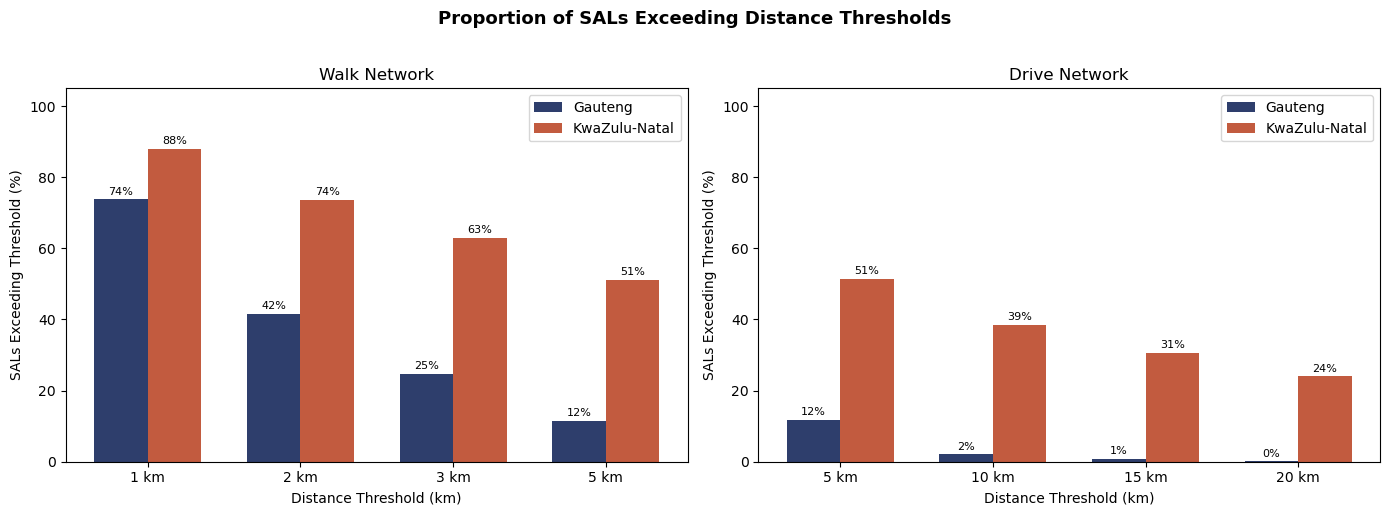

SAVED: images/threshold_exceedance_by_province.png


In [34]:
# FIGURE 1: Province-level exceedance by threshold (walk and drive).
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.patch.set_facecolor("white")

bar_colors = {"Gauteng": "#2e3e6c", "KwaZulu-Natal": "#c25b3f"}

for ax_idx, mode in enumerate(["walk", "drive"]):
    ax = axes[ax_idx]
    col = available_modes.get(mode)
    if col is None:
        ax.set_visible(False)
        continue

    thresholds = threshold_config[mode]
    mode_flags = [f"exceeds_{mode}_{t}km" for t in thresholds]
    table = compute_exceedance_table(df, mode_flags, "PR_NAME")

    x = np.arange(len(thresholds))
    width = 0.35

    for i, province in enumerate(["Gauteng", "KwaZulu-Natal"]):
        if province in table.index:
            vals = table.loc[province, mode_flags].values * 100
            ax.bar(x + i * width, vals, width, label = province, color = bar_colors[province])

    ax.set_xlabel("Distance Threshold (km)")
    ax.set_ylabel("SALs Exceeding Threshold (%)")
    ax.set_title(f"{mode.capitalize()} Network")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([f"{t} km" for t in thresholds])
    ax.legend()
    ax.set_ylim(0, 105)

    # Add value labels on bars.
    for container in ax.containers:
        ax.bar_label(container, fmt = "%.0f%%", padding = 2, fontsize = 8)

plt.suptitle("Proportion of SALs Exceeding Distance Thresholds", fontsize = 13, fontweight = "bold", y = 1.02)
plt.tight_layout()
plt.savefig("images/threshold_exceedance_by_province.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("SAVED: images/threshold_exceedance_by_province.png")

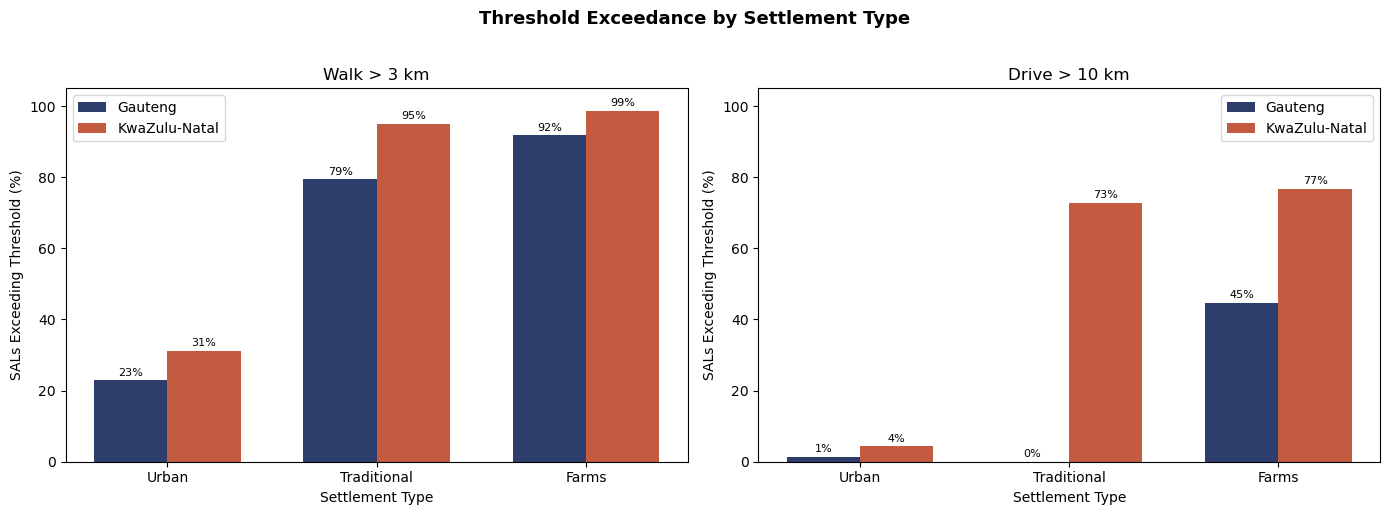

SAVED: images/threshold_exceedance_by_settlement.png


In [35]:
# FIGURE 2: Settlement type breakdown for key thresholds (walk 3km, drive 10km).
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.patch.set_facecolor("white")

settlement_colors = {"Urban": "#4c72b0", "Traditional": "#c44e52", "Farms": "#8c8c8c"}
key_thresholds = {"walk": 3, "drive": 10}

for ax_idx, (mode, t) in enumerate(key_thresholds.items()):
    ax = axes[ax_idx]
    col = available_modes.get(mode)
    if col is None:
        ax.set_visible(False)
        continue

    flag_col = f"exceeds_{mode}_{t}km"
    if flag_col not in df.columns:
        ax.set_visible(False)
        continue

    # Compute exceedance by province x settlement type.
    pivot = df.pivot_table(
        values = flag_col,
        index = "EA_GTYPE",
        columns = "PR_NAME",
        aggfunc = "mean"
    ) * 100
    pivot = pivot.reindex(SETTLEMENT_ORDER).dropna(how = "all")

    x = np.arange(len(pivot.index))
    width = 0.35
    provinces = [p for p in ["Gauteng", "KwaZulu-Natal"] if p in pivot.columns]

    for i, province in enumerate(provinces):
        vals = pivot[province].values
        ax.bar(x + i * width, vals, width, label = province, color = bar_colors[province])

    ax.set_xlabel("Settlement Type")
    ax.set_ylabel("SALs Exceeding Threshold (%)")
    ax.set_title(f"{mode.capitalize()} > {t} km")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(pivot.index)
    ax.legend()
    ax.set_ylim(0, 105)

    for container in ax.containers:
        ax.bar_label(container, fmt = "%.0f%%", padding = 2, fontsize = 8)

plt.suptitle("Threshold Exceedance by Settlement Type", fontsize = 13, fontweight = "bold", y = 1.02)
plt.tight_layout()
plt.savefig("images/threshold_exceedance_by_settlement.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("SAVED: images/threshold_exceedance_by_settlement.png")

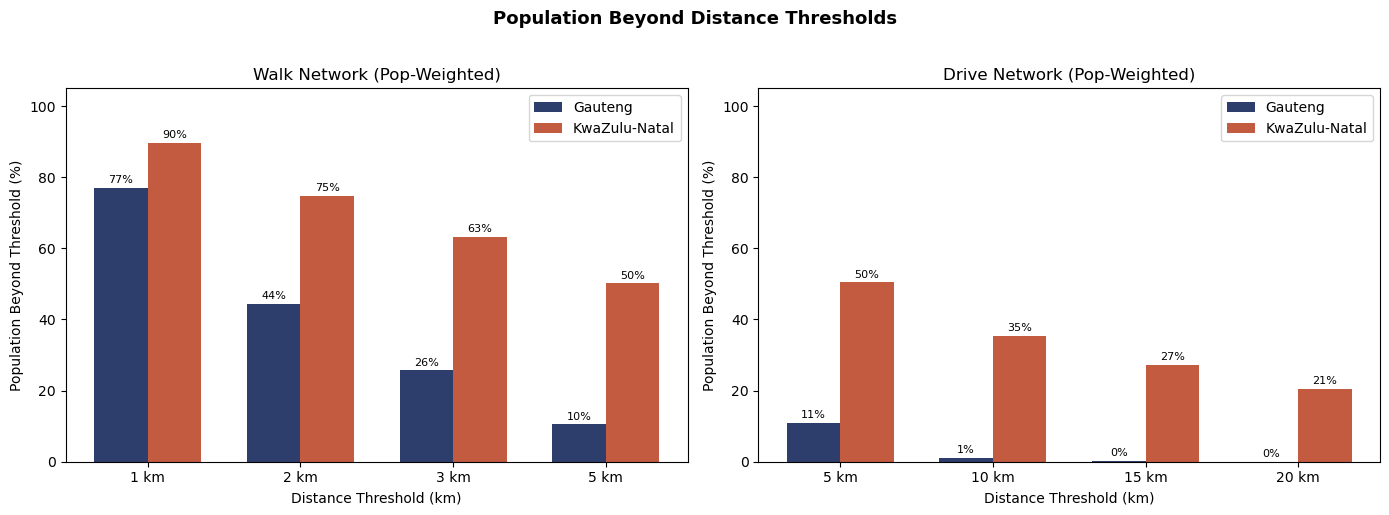

SAVED: images/threshold_exceedance_popweighted.png


In [36]:
# FIGURE 3: Population-weighted exceedance for walk and drive across all thresholds.
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.patch.set_facecolor("white")

for ax_idx, mode in enumerate(["walk", "drive"]):
    ax = axes[ax_idx]
    col = available_modes.get(mode)
    if col is None:
        ax.set_visible(False)
        continue

    thresholds = threshold_config[mode]
    mode_flags = [f"exceeds_{mode}_{t}km" for t in thresholds]
    table = compute_exceedance_table(df, mode_flags, "PR_NAME", weight_col = "sal2023_est")

    x = np.arange(len(thresholds))
    width = 0.35

    for i, province in enumerate(["Gauteng", "KwaZulu-Natal"]):
        if province in table.index:
            vals = table.loc[province, mode_flags].values * 100
            ax.bar(x + i * width, vals, width, label = province, color = bar_colors[province])

    ax.set_xlabel("Distance Threshold (km)")
    ax.set_ylabel("Population Beyond Threshold (%)")
    ax.set_title(f"{mode.capitalize()} Network (Pop-Weighted)")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([f"{t} km" for t in thresholds])
    ax.legend()
    ax.set_ylim(0, 105)

    for container in ax.containers:
        ax.bar_label(container, fmt = "%.0f%%", padding = 2, fontsize = 8)

plt.suptitle("Population Beyond Distance Thresholds", fontsize = 13, fontweight = "bold", y = 1.02)
plt.tight_layout()
plt.savefig("images/threshold_exceedance_popweighted.png", dpi = 150, bbox_inches = "tight")
plt.show()
print("SAVED: images/threshold_exceedance_popweighted.png")

## HEATMAP: FULL CROSS-TABULATION

A single heatmap showing exceedance rates across all combinations
of province, settlement type, and threshold for quick visual
comparison.

In [37]:
# Build full cross-tab for heatmap.
heatmap_rows = []

for mode in ["walk", "drive"]:
    col = available_modes.get(mode)
    if col is None:
        continue
    thresholds = threshold_config[mode]
    mode_flags = [f"exceeds_{mode}_{t}km" for t in thresholds]

    for province in ["Gauteng", "KwaZulu-Natal"]:
        prov_df = df[df["PR_NAME"] == province]
        for stype in SETTLEMENT_ORDER:
            stype_df = prov_df[prov_df["EA_GTYPE"] == stype]
            if len(stype_df) == 0:
                continue
            row = {"Province": province, "Settlement": stype, "Mode": mode.capitalize(), "n": len(stype_df)}
            for fc, t in zip(mode_flags, thresholds):
                row[f"{t} km"] = stype_df[fc].mean() * 100
            heatmap_rows.append(row)

heatmap_df = pd.DataFrame(heatmap_rows)
heatmap_df["Label"] = heatmap_df["Province"].str[:3] + " / " + heatmap_df["Settlement"]

print("FULL EXCEEDANCE CROSS-TAB (% of SALs)")
print(heatmap_df.to_string(index = False))

FULL EXCEEDANCE CROSS-TAB (% of SALs)
     Province  Settlement  Mode     n     1 km    2 km    3 km    5 km   10 km   15 km   20 km             Label
      Gauteng       Urban  Walk 20596  73.0287 40.0952 22.8491  9.9534     NaN     NaN     NaN       Gau / Urban
      Gauteng Traditional  Walk   257  98.4436 92.2179 79.3774 45.9144     NaN     NaN     NaN Gau / Traditional
      Gauteng       Farms  Walk   329 100.0000 98.4802 91.7933 82.3708     NaN     NaN     NaN       Gau / Farms
KwaZulu-Natal       Urban  Walk  9037  76.6847 49.8064 31.1497 13.2566     NaN     NaN     NaN       Kwa / Urban
KwaZulu-Natal Traditional  Walk  8166  99.2408 97.3304 94.9057 89.0277     NaN     NaN     NaN Kwa / Traditional
KwaZulu-Natal       Farms  Walk   792 100.0000 99.4949 98.6111 92.2980     NaN     NaN     NaN       Kwa / Farms
      Gauteng       Urban Drive 20596      NaN     NaN     NaN 10.2884  1.4323  0.4030  0.0049       Gau / Urban
      Gauteng Traditional Drive   257      NaN     NaN    

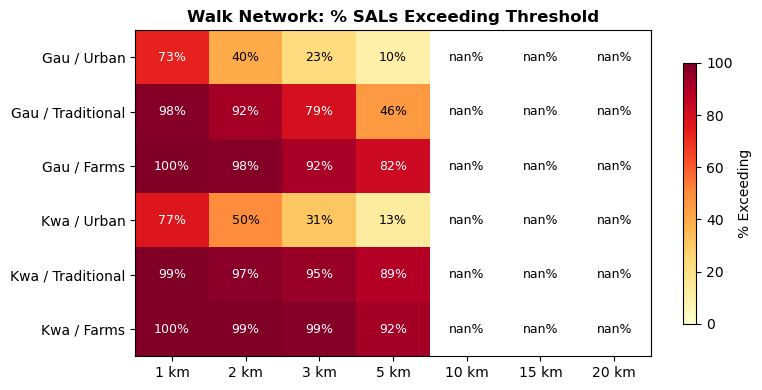

SAVED: images/threshold_heatmap_walk.png


In [38]:
# Heatmap for walk thresholds.
walk_heat = heatmap_df[heatmap_df["Mode"] == "Walk"].copy()
if len(walk_heat) > 0:
    walk_threshold_cols = [c for c in walk_heat.columns if c.endswith(" km")]
    walk_matrix = walk_heat.set_index("Label")[walk_threshold_cols].astype(float)

    fig, ax = plt.subplots(figsize = (8, 4))
    im = ax.imshow(walk_matrix.values, cmap = "YlOrRd", aspect = "auto", vmin = 0, vmax = 100)

    ax.set_xticks(range(len(walk_threshold_cols)))
    ax.set_xticklabels(walk_threshold_cols)
    ax.set_yticks(range(len(walk_matrix.index)))
    ax.set_yticklabels(walk_matrix.index)

    # Annotate cells.
    for i in range(walk_matrix.shape[0]):
        for j in range(walk_matrix.shape[1]):
            val = walk_matrix.iloc[i, j]
            color = "white" if val > 60 else "black"
            ax.text(j, i, f"{val:.0f}%", ha = "center", va = "center", color = color, fontsize = 9)

    ax.set_title("Walk Network: % SALs Exceeding Threshold", fontweight = "bold")
    plt.colorbar(im, ax = ax, label = "% Exceeding", shrink = 0.8)
    plt.tight_layout()
    plt.savefig("images/threshold_heatmap_walk.png", dpi = 150, bbox_inches = "tight")
    plt.show()
    print("SAVED: images/threshold_heatmap_walk.png")

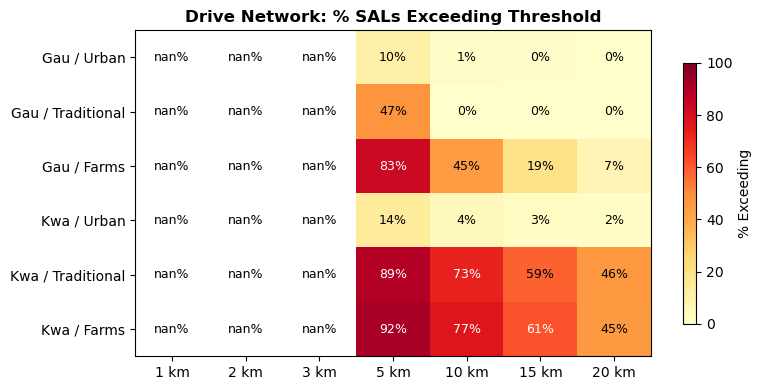

SAVED: images/threshold_heatmap_drive.png


In [39]:
# Heatmap for drive thresholds.
drive_heat = heatmap_df[heatmap_df["Mode"] == "Drive"].copy()
if len(drive_heat) > 0:
    drive_threshold_cols = [c for c in drive_heat.columns if c.endswith(" km")]
    drive_matrix = drive_heat.set_index("Label")[drive_threshold_cols].astype(float)

    fig, ax = plt.subplots(figsize = (8, 4))
    im = ax.imshow(drive_matrix.values, cmap = "YlOrRd", aspect = "auto", vmin = 0, vmax = 100)

    ax.set_xticks(range(len(drive_threshold_cols)))
    ax.set_xticklabels(drive_threshold_cols)
    ax.set_yticks(range(len(drive_matrix.index)))
    ax.set_yticklabels(drive_matrix.index)

    for i in range(drive_matrix.shape[0]):
        for j in range(drive_matrix.shape[1]):
            val = drive_matrix.iloc[i, j]
            color = "white" if val > 60 else "black"
            ax.text(j, i, f"{val:.0f}%", ha = "center", va = "center", color = color, fontsize = 9)

    ax.set_title("Drive Network: % SALs Exceeding Threshold", fontweight = "bold")
    plt.colorbar(im, ax = ax, label = "% Exceeding", shrink = 0.8)
    plt.tight_layout()
    plt.savefig("images/threshold_heatmap_drive.png", dpi = 150, bbox_inches = "tight")
    plt.show()
    print("SAVED: images/threshold_heatmap_drive.png")

## POLICY SUMMARY TABLE

Formatted output for direct use in reports. Each row answers:
at threshold X, what proportion of SALs (and people) in each
province cannot reach a pharmacy?

In [40]:
# Build a clean summary table for report use.
summary_rows = []

for mode in ["walk", "drive"]:
    col = available_modes.get(mode)
    if col is None:
        continue
    thresholds = threshold_config[mode]

    for t in thresholds:
        flag_col = f"exceeds_{mode}_{t}km"
        for province in ["Gauteng", "KwaZulu-Natal"]:
            prov_df = df[df["PR_NAME"] == province]
            n_total = len(prov_df)
            n_exceed = prov_df[flag_col].sum()
            pct_sal = n_exceed / n_total * 100

            pop_total = prov_df["sal2023_est"].sum()
            pop_exceed = prov_df.loc[prov_df[flag_col], "sal2023_est"].sum()
            pct_pop = pop_exceed / pop_total * 100 if pop_total > 0 else np.nan

            summary_rows.append({
                "Mode": mode.capitalize(),
                "Threshold (km)": t,
                "Province": province,
                "SALs Total": n_total,
                "SALs Exceeding": int(n_exceed),
                "% SALs": round(pct_sal, 1),
                "Pop Exceeding": int(pop_exceed),
                "% Pop": round(pct_pop, 1)
            })

summary_df = pd.DataFrame(summary_rows)
print("POLICY SUMMARY TABLE")
print(summary_df.to_string(index = False))

POLICY SUMMARY TABLE
 Mode  Threshold (km)      Province  SALs Total  SALs Exceeding  % SALs  Pop Exceeding   % Pop
 Walk               1       Gauteng       21182           15623 73.8000       11839303 76.9000
 Walk               1 KwaZulu-Natal       17995           15826 87.9000       11379231 89.6000
 Walk               2       Gauteng       21182            8819 41.6000        6825322 44.4000
 Walk               2 KwaZulu-Natal       17995           13237 73.6000        9503328 74.8000
 Walk               3       Gauteng       21182            5212 24.6000        3950860 25.7000
 Walk               3 KwaZulu-Natal       17995           11346 63.1000        8028969 63.2000
 Walk               5       Gauteng       21182            2439 11.5000        1615245 10.5000
 Walk               5 KwaZulu-Natal       17995            9199 51.1000        6366967 50.1000
Drive               5       Gauteng       21182            2512 11.9000        1681178 10.9000
Drive               5 KwaZulu

## EXPORT RESULTS

In [42]:
# Export the analysis table with all threshold flags.
export_cols = ["EA_CODE", "PR_NAME", "EA_GTYPE", "EA_TYPE", "econ_status", "sal2023_est"]

# Add distance columns.
for mode, col in available_modes.items():
    export_cols.append(col)

# Add flag columns.
export_cols.extend(flag_columns)

# Filter to columns that exist.
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv("data/networks/k3_network_threshold_summary.csv", index = False)
print(f"EXPORTED: data/networks/k3_network_threshold_summary.csv")
print(f"Rows: {len(df)}, Columns: {len(export_cols)}")

# Export the summary table.
summary_df.to_csv("data/networks/k3_network_threshold_summary.csv", index = False)
print(f"EXPORTED: data/networks/k3_network_threshold_summary.csv")

EXPORTED: data/networks/k1_network_threshold_summary.csv
Rows: 39177, Columns: 21
EXPORTED: data/networks/k1_network_threshold_summary.csv


## NOTES AND LIMITATIONS

- **k=1 only.** This analysis uses distance to the single nearest pharmacy.
  A SAL that passes the 3 km walk threshold has *one* pharmacy within reach,
  but that pharmacy may be overloaded. The 2SFCA handles demand-side pressure;
  this notebook intentionally does not.

- **Centroid assumption.** Distances are measured from geometric SAL centroids.
  For large or irregularly shaped SALs (common in rural KZN), some residents
  may be significantly farther from the nearest pharmacy than the centroid
  distance suggests.

- **OSM network completeness.** Missing roads in informal settlements and rural
  areas cause the algorithm to route around gaps, inflating computed distances.
  Walk distances in these areas may overestimate true pedestrian travel where
  informal footpaths exist.

- **Threshold selection.** The thresholds (e.g., 3 km walk, 10 km drive) are
  policy-relevant reference points but inherently arbitrary. A SAL at 3.1 km
  is classified differently from one at 2.9 km despite near-identical access.
  The multi-threshold approach mitigates this by showing the full exceedance
  curve rather than a single binary cut.

- **No transit mode.** The dominant transport mode for many South Africans
  (minibus taxi) is not captured in either the walk or drive network. A SAL
  classified as exceeding the walk threshold may be well-served by a taxi
  route that passes through a pharmacy cluster.